In [1]:
### Import section

%matplotlib inline
%load_ext autoreload
%autoreload 2

### environment settings BEFORE importing numpy and scipy
# necessary for parallelization in linux systems
import os

os.environ.setdefault("OMP_NUM_THREADS","1")
os.environ.setdefault("MKL_NUM_THREADS","1")
os.environ.setdefault("OPENBLAS_NUM_THREADS","1")
os.environ.setdefault("NUMEXPR_NUM_THREADS","1")

# import of necessary tools: built-in, installed
import copy, sys, time, concurrent.futures, glob, matplotlib
import numpy             as     np
import nibabel           as     nib
import matplotlib.pyplot as     plt
from   matplotlib.lines  import Line2D
from   scipy.io          import savemat

# import of necessary tools: own scripts and classes
# have to be stored in the same directory as the main script
import helpTools             as     hlp
from   PSOworkflow_v2        import ParticleSwarmOptimizer as PSOclass
from   PSOpreparation_v2_SI  import PSOpreparation         as PSOprep
from   PSOplots_v2           import PSOgrafics, PSOvideos

# import main modules for single (SI) and joint (JI) inversion
from   PSOmain_v2_SI_yupiter import run_PSO_on_config as run_PSO_SI
from   PSOmain_v2_JI_yupiter import run_PSO_on_config as run_PSO_JI

In [2]:
### Some helper functions outside of the PSO package
import random

def random_2d_vector(x_range, y_range):
    x = random.uniform(x_range[0], x_range[1])
    y = random.uniform(y_range[0], y_range[1])
    return (x, y)

def divisors(n):
    return [i for i in range(1, n+1) if n % i == 0]

In [3]:
### USER SECTION: Definition of the main project path and further globals

# !!!
# path structure required for successful PSO execution: /project_path/data_set/[mask/sgm_se0.nii.gz, nifti/*.nii, config.yaml]

# project path
project_path = 'F:/JIMM2/MWF_invivo/DZNE_Data'

# which config type to use: 'file' --> uses config_filelist, 'dict' --> uses, e.g., client_list + config_dict)
config_type  = 'dict'

# list of MRI signals available for inversion
all_signals  = ['T1', 'T2', 'T2S', 'CT2S']

# list of configuration files
config_filelist = [f'{project_path}/24_10_10_a/config_24_10_10_a.yaml',
                   f'{project_path}/24_10_10_b/config_24_10_10_b.yaml',
                   f'{project_path}/24_10_10_c/config_24_10_10_c.yaml',
                   f'{project_path}/25_08_20_a/config_25_08_20_a.yaml',
                   f'{project_path}/25_08_20_b/config_25_08_20_b.yaml',
                   f'{project_path}/25_08_28_a/config_25_08_28_a.yaml',
                   f'{project_path}/25_08_28_b/config_25_08_28_b.yaml',
                   f'{project_path}/25_09_01_a/config_25_09_01_a.yaml',
                   f'{project_path}/25_09_01_b/config_25_09_01_b.yaml',]

# list of data sets
# (a)
client_list = ['24_10_10_a', '24_10_10_b', '24_10_10_c', '25_08_20_a', '25_08_20_b', '25_08_28_a', '25_08_28_b', '25_09_01_a', '25_09_01_b']
# client_list = [d for d in os.listdir(project_path) if os.path.isdir(os.path.join(project_path, d))]

# (b)
signal_list = ['T2', 'T2S', 'CT2S']
pixel_list  = [[45,45], [30,70]]

In [4]:
### Dictionary Configuration (default) for PSO approach - mainly coherent to YAML config file content

### NOTE: do changes in the single cells of specific PSO applications, as this here is showing default adjustments

config_dict = {
    "general": {"PSO_vs": ""},

    "source": {
        "file": {"prj_dir": "", "T1": "", "T2": "", "T2S": "", "CT2S": "", "TE": "", "B1": "", "ATLAS": ""},
        "signal": {"T1": False, "T2": False, "T2S": False, "CT2S": False, "SI": False, "JI": False},
        "data": {"obs_data": "", "add_noise": [False, 0], "gauss_filt": [False, [0.0, 0.0, 0]], "norm_max": False},
        "mask": {"use": False, "seg": [], "path": ""},
    },

    "PSO_spec": {
        "calc": {
            "performance_test": {"use": False}, "calibration_test": {"use": False},
            "iter_test": {"use": False, "slice": 0, "pixli": [], "gif": False},
            "PSO_on_slice": {"use": False, "start": 0, "end": 0},
            "PSO_on_pixel": {"use": False, "slice": 0, "pixli": []},
        },
        "math": {"width": 0, "batch": 0, "njit": False},
        "dyn": {"rand": [False, 0], "slice": 0, "pixel": [0, 0]},
        "iter": 0, "part": 0,
        "PSO_iter": {"slice": 0, "pixel": 0},
        "lp_norm": "", "mod_vec": "", "peaks": "", "curve": "",
    },
}

# general
config_dict['general']['PSO_vs'] = "2.0.0"

# source -> file (files have to be located in prj_Dir/nifti/)
config_dict['source']['file']['prj_dir'] = f'{project_path}/24_10_10_a/'
config_dict['source']['file']['T1']      = 'NO_FILE'                          # (not measured in the 2023/2024/2025 sessions)
config_dict['source']['file']['T2']      = 'mese_run1.nii'                    # multi echo spin echo
config_dict['source']['file']['T2S']     = 'mege_mag_run1.nii'                # multi echo gradient echo
config_dict['source']['file']['CT2S']    = 'mege_phs_run1.nii'                # T2S phase information
config_dict['source']['file']['TE']      = 'te.npy'                           # 1D-array of TE times
config_dict['source']['file']['B1']      = 'dream_resampled.nii'              # radiofrequency (RF) transmit field
config_dict['source']['file']['ATLAS']   = 'Atlas_Mean.nii'                   # atlas of predefined MFW distribution in a brain

# source -> signal
config_dict['source']['signal']['T1']   = False
config_dict['source']['signal']['T2']   = True
config_dict['source']['signal']['T2S']  = False
config_dict['source']['signal']['CT2S'] = False
config_dict['source']['signal']['SI']   = True
config_dict['source']['signal']['JI']   = False

# source -> data
config_dict['source']['data']['obs_data']   = 'invivo'                      # ['invivo', 'atlas'] - for now we use only measured data
config_dict['source']['data']['add_noise']  = [False, 150]                  # [[True/False], SNR] - noise to observed data (use for MWF Atlas)
config_dict['source']['data']['gauss_filt'] = [False, [1.0,1.0,0]]          # spatial Gaussian smoothing filter using sigma as in [sx,sy,sz]
config_dict['source']['data']['norm_max']   = True                          # [True/False] - normalization of observed data to max value of decay

# source -> mask
config_dict['source']['mask']['use']  = True
config_dict['source']['mask']['seg']  = [3,4,5]                               # 1.CSF, 2.Gray Matter (GM), 3.White Matter (WM)
                                                                              # 4.Deep Gray Matter (dGM), 5.Brain Stem (BS), 6.Cerebellum (CB)
config_dict['source']['mask']['path'] = 'mask/sgm_se0.nii.gz'                 # relative mask path within your project directory 

# PSO_spec -> calc
config_dict['PSO_spec']['calc']['performance_test']['use'] = False              # for developer
config_dict['PSO_spec']['calc']['calibration_test']['use'] = False              # for developer
config_dict['PSO_spec']['calc']['iter_test']['use']        = False              # for developer
config_dict['PSO_spec']['calc']['iter_test']['slice']      = 7                  # for developer
config_dict['PSO_spec']['calc']['iter_test']['pixli']      = [[45,45], [30,70]] # for developer
config_dict['PSO_spec']['calc']['iter_test']['gif']        = False              # for developer

config_dict['PSO_spec']['calc']['PSO_on_slice']['use']     = True              # [True/False] - perform PSO slice-wise (along the 'Z' direction)
config_dict['PSO_spec']['calc']['PSO_on_slice']['start']   = 0                 # ID [int] of the start slice (note: Python indexing starts at 0)
config_dict['PSO_spec']['calc']['PSO_on_slice']['end']     = 24                # ID [int] of the end slice (note: end index is exclusive)
config_dict['PSO_spec']['calc']['PSO_on_pixel']['use']     = False             # [True/False] - perform PSO pixel-wise
config_dict['PSO_spec']['calc']['PSO_on_pixel']['slice']   = 7                 # slice number (along the 'Z' direction)
config_dict['PSO_spec']['calc']['PSO_on_pixel']['pixel']   = [[50,65], [30,70], [50,55]] # list of pixels for PSO_on_pixel execution

# PSO_spec -> math
config_dict['PSO_spec']['math']['width'] = 10      # Gaussian bell width as y → 0, which can be estimated within the error interval (~6.5)
config_dict['PSO_spec']['math']['batch'] = 16      # batch size / number of curves used to calculate Gaussian bells within the model space
config_dict['PSO_spec']['math']['njit']  = True    # use / don't use numba njit acceleration
config_dict['PSO_spec']['math']['norm']  = True    # use / don't use norm to max value for synthetic data curves (recommended)

# PSO_spec -> dyn
config_dict['PSO_spec']['dyn']['rand']  = [True,0]
config_dict['PSO_spec']['dyn']['slice'] = 18
config_dict['PSO_spec']['dyn']['pixel'] = [0, 0]

# PSO_spec -> iter / part
config_dict['PSO_spec']['iter'] = 75                    # number of iterations during PSO execution
config_dict['PSO_spec']['part'] = 400                   # number of particles used for PSO execution

# PSO_spec -> PSO_iter
config_dict['PSO_spec']['PSO_iter']['slice'] = 100      # number of cycles of individual PSO executions on a slice
config_dict['PSO_spec']['PSO_iter']['pixel'] = 10000    # number of cycles of individual PSO executions on a pixel

# PSO_spec -> weitere
config_dict['PSO_spec']['lp_norm'] = 'L2'               # ['L1','L2']: LP-NORM --> L1-Norm: Manhattan & L2-Norm: Euclidean
config_dict['PSO_spec']['mod_vec'] = 'V0'               # [V0,V1]: number of modelvectors --> V0: 2 & V1: 1
config_dict['PSO_spec']['peaks']   = 'GAUSS'            # ['GAUSS', 'DIRAC'] - GAUSS - 2 peaks - m1(MW), m2(FW) | DIRAC - 3 peaks - m1(MW), m2(AW), m3(EW)
config_dict['PSO_spec']['curve']   = 'GAUSS'            # ['GAUSS', 'DIRAC'] - GAUSS: integration over a bell-shape | DIRAC: integration using peaks without sigma

In [5]:
### FIGURE 1: PSO inversion of synthetic ME-SE data based on MWF atlas
signal_list = ['T2']
iterations  = 15
particles   = 32  
repetitions = 100

###
PSO_results_array = {sig: [] for sig in signal_list}
system_parameters = {sig: [] for sig in signal_list}
synDat_array      = {sig: [] for sig in signal_list}

_config_dict      = copy.deepcopy(config_dict)

_config_dict['source']['file']['prj_dir']   = f'{project_path}/MWF_Atlas/'
_config_dict["source"]["data"]["add_noise"] = [True, 150]
_config_dict["source"]["mask"]["use"]       = False
_config_dict["source"]["file"]["TE"]        = 'te_32.npy'
_config_dict["source"]["data"]["obs_data"]  = 'atlas'

_config_dict['PSO_spec']['math']['norm']                  = True
_config_dict['PSO_spec']['iter']                          = iterations
_config_dict['PSO_spec']['part']                          = particles
_config_dict['PSO_spec']['PSO_iter']['slice']             = repetitions
_config_dict["PSO_spec"]["calc"]["PSO_on_slice"]["start"] = 90
_config_dict["PSO_spec"]["calc"]["PSO_on_slice"]["end"]   = 90 + 1

sig_config = dict(_config_dict["source"]["signal"])

for i, item in enumerate(signal_list):
    
    for sig in all_signals:
        if item == "CT2S":
            sig_config["T2S"]  = True
            sig_config["CT2S"] = True
            sig_config["T1"]   = False
            sig_config["T2"]   = False
        else:
            sig_config[sig] = (sig == item)

    _config_dict["source"]["signal"] = sig_config
    
    print(f'Dataset: MWF Atlas | Signal: {item} | Inversion: single')
    synDat_array[item], PSO_results_array[item], system_parameters[item] = run_PSO_SI(config_input=_config_dict, config_type='dict')

fig_1_data  = copy.deepcopy(PSO_results_array)
fig_1_syn   = copy.deepcopy(synDat_array)
fig_1_param = copy.deepcopy(system_parameters)

Dataset: MWF Atlas | Signal: T2 | Inversion: single

Calling measurement data ...
Spatial gaussian smoothing filter: False
Execution time: 00:00:00 hrs

Calculating PSO system constants ...
Execution time: 00:00:00 hrs

Starttime for PSO routine (GMT): 11:05:21

Execution time preparation of sys param: : 00:00:19 hrs

Execute PSO inversion - signal: T2 | slice: 90 | noPeaks: GAUSS

Execution time slice 90: : 00:09:57 hrs

Execution time all together: : 00:09:58 hrs


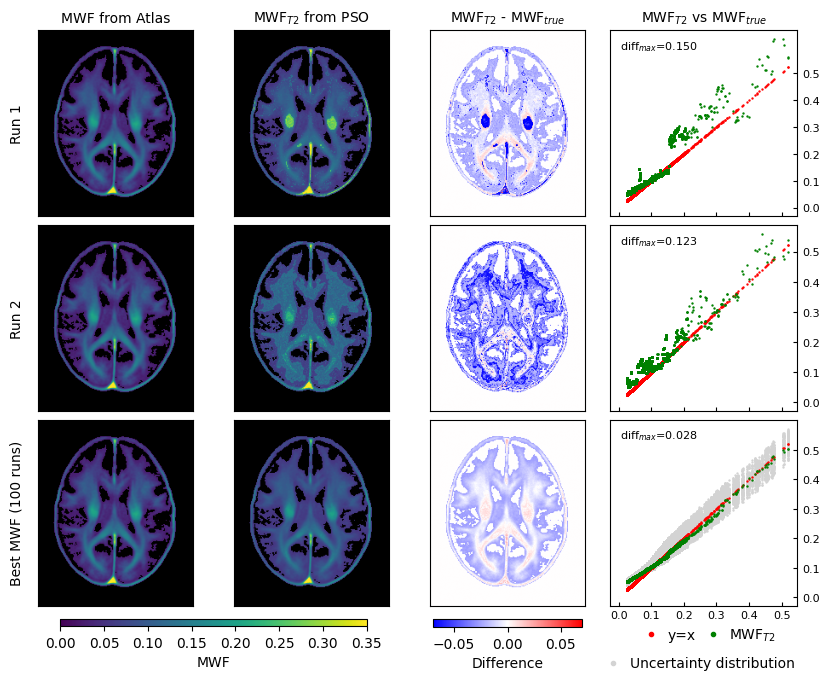

In [6]:
### FIGURE 1: plot and save

save_dir    = os.path.join(os.getcwd(), 'ISMRM_2026')

figure_name = 'fig1.png'
savepath    = os.path.join(save_dir, figure_name); os.makedirs(save_dir, exist_ok=True)

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax     = plt.subplots(3,4, figsize=(10, 9), gridspec_kw={'hspace': 0.05, 'wspace': 0.05})

cmap        = matplotlib.colormaps.get_cmap('viridis')
cmap.set_bad(color='black')
labels      = ['Run 1', 'Run 2', 'Best MWF (100 runs)']

MWF_atlas   = fig_1_param['T2'].obs_data['MWF_ATLAS'][...,90]*fig_1_param['T2'].masks['T2'][...,0]
MWF_copy_a  = copy.deepcopy(MWF_atlas)
MWF_copy_b  = copy.deepcopy(MWF_atlas)

mask        = fig_1_param['T2'].masks['T2'][..., 0]
mask_atlas  = MWF_atlas <= 0.025
MWF_copy_a[~mask_atlas] = np.nan
MWF_copy_b[mask_atlas]  = np.nan

list_3_percent = []

for i,j in enumerate([0,1,-1]):
    PSO_results             = np.nan_to_num(fig_1_data['T2']['T2'][5, :, :, j], nan=0.0)
    diff_map                = MWF_atlas - PSO_results
    PSO_results[mask == 0]  = np.nan

    # First Column: MWF Atlas map
    im0 = ax[i,0].imshow(np.rot90(MWF_copy_b),cmap=cmap,vmin=0,vmax=0.35)    

    # Second Column: MWF map from PSO (Signal T2)
    im1 = ax[i,1].imshow(np.rot90(PSO_results),cmap=cmap,vmin=0,vmax=0.35)

    # Third Column: Differences map MWF Atlas - MWF PSO
    im2 = ax[i,2].imshow(np.rot90(diff_map), cmap='bwr', vmin=-0.07, vmax=0.07)
    ax[i,2].add_patch(plt.Rectangle((0, 0), PSO_results.shape[0], PSO_results.shape[1],
                                    edgecolor='black', facecolor='none', lw=0.001))
    
    # Fourth Column: True versus estimated MWF values, scattered 
    ax[i,3].scatter(MWF_atlas, MWF_atlas, s=0.5, c='r')
    ax[i,3].scatter(MWF_copy_a, MWF_copy_a, s=0.6, c='w')
    ax[i,3].scatter(MWF_atlas, PSO_results, s=0.5, c='g')
    ax[i,3].text(0.05, 0.9, rf'diff$_{{max}}$={np.max(np.abs(diff_map)):.3f}',
                transform=ax[i, 3].transAxes, fontsize=8)

    if j == -1:
        MWF_results = np.nan_to_num(fig_1_data['T2']['T2'][5, :, :, :], nan=0.0)
        FIT_results = np.nan_to_num(fig_1_data['T2']['T2'][6, :, :, :], nan=0.0)
        min_val = np.min(FIT_results, axis=2)

        min_per_pixel = np.min(FIT_results, axis=2, keepdims=True)
        _mask = FIT_results <= min_per_pixel * 1.03

        corridor_fits = np.where(_mask, FIT_results, np.nan)
        corridor_pso  = np.where(_mask, MWF_results, np.nan)

        for k in range(corridor_pso.shape[-1]):
            if k == corridor_pso.shape[-1]-1:
                ax[i,3].scatter(MWF_atlas, MWF_atlas, s=0.5, c='r')
                ax[i,3].scatter(MWF_copy_a, MWF_copy_a, s=0.6, c='w')
            
            color = 'g' if k == corridor_pso.shape[-1]-1 else 'lightgray'
            ax[2,3].scatter(MWF_copy_b[~np.isnan(corridor_pso[...,k])], corridor_pso[...,k][~np.isnan(corridor_pso[...,k])], s=0.5, c=color)
        
    # Layout: Axis and titles
    ax[i,0].set_ylabel(labels[i], fontsize=10, labelpad=10)
    
    for p in range(3):
        ax[i,p].set_xticks([])
        ax[i,p].set_yticks([])

    ax[i,3].tick_params(axis='x', direction='in', top=False, bottom=True, labelbottom=False, length=3)
    ax[i,3].tick_params(axis='y', direction='in', left=False, right=True, labelleft=False, labelright=True, length=3)

    ax[i,3].set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
    ax[i,3].set_xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
    ax[i,3].set_yticklabels(['0.0', '0.1', '0.2', '0.3', '0.4', '0.5'], fontsize=8)

    if i == 2:
        ax[i,3].tick_params(axis='x', direction='in', top=False, bottom=True, labelbottom=True, length=3)
        ax[i,3].set_xticklabels(['0.0', '0.1', '0.2', '0.3', '0.4', '0.5'], fontsize=8)  
    
    if i == 0:
        ax[i,0].set_title(r'MWF from Atlas', fontsize=10)
        ax[i,1].set_title(r'MWF$_{T2}$ from PSO', fontsize=10)
        ax[i,2].set_title(r'MWF$_{T2}$ - MWF$_{true}$',fontsize=10)
        ax[i,3].set_title(r'MWF$_{T2}$ vs MWF$_{true}$',fontsize=10)

# Colorbars
cbar1 = fig.colorbar(im1, ax=ax[:, :2], orientation='horizontal', shrink=0.8, pad=0.02, aspect=45)
cbar1.set_label('MWF', fontsize=10)

cbar2 = fig.colorbar(im2, ax=ax[:, 2], orientation='horizontal', shrink=0.8, pad=0.02, aspect=20)
cbar2.set_label('Difference', fontsize=10)

# Adjust Column 4 to the size of the other columns
for i in range(3):
    box1 = ax[i, 0].get_position()
    box3 = ax[i, 3].get_position()
    ax[i, 3].set_position([box3.x0, box1.y0, box3.width, box1.height])

# === Gemeinsame horizontale Legende unter Column 3 ===
handles1 = [Line2D([], [], marker='o', markersize=3, color='r', linestyle='', label='y=x'),
            Line2D([], [], marker='o', markersize=3, color='g', linestyle='', label=r'MWF$_{T2}$')]

handles2 = [Line2D([], [], marker='o', markersize=3, color='lightgray', linestyle='', label=r'Uncertainty distribution')]

fig.legend(handles=handles1, loc='lower center', bbox_to_anchor=(0.81, 0.185), 
           handletextpad=0.2, columnspacing=0.2, ncol=2, fontsize=10, frameon=False)
fig.legend(handles=handles2, loc='lower center', bbox_to_anchor=(0.80, 0.155), 
           handletextpad=0.2, columnspacing=0.2, ncol=2, fontsize=10, frameon=False)

fig.set_facecolor('w')
fig.savefig(f'{savepath}', dpi=300, format='png', bbox_inches='tight')
plt.show()

In [16]:
### FIGURE 2: PSO inversion of in-vivo ME-SE data - 3 subjects / 3 pre-analysis levels (raw, degibbsed, denoised)
_client_list = client_list[:3]
_file_list   = ['mese_run1.nii', 'mese_run1_degibbsed.nii', 'mese_run1_denoised.nii']

PSO_signal   = 'T2'
sig_config   = dict(config_dict["source"]["signal"])
PSO_cycles   = 100
slice_num    = 7
dataset_spec = ['raw', 'degibbsed', 'denoised']

PSO_results_array = {client: {ff: [] for ff in dataset_spec} for client in _client_list}
system_parameters = {client: {ff: [] for ff in dataset_spec} for client in _client_list}
synDat_array      = {client: {ff: [] for ff in dataset_spec} for client in _client_list}

_config_dict      = copy.deepcopy(config_dict)
                    
for data_set in _client_list:
        
    _config_dict['source']['file']['prj_dir']     = f'{project_path}/{data_set}/'
    _config_dict['PSO_spec']['iter']              = 15
    _config_dict['PSO_spec']['part']              = 32
    _config_dict['PSO_spec']['math']['norm']      = True
    _config_dict['PSO_spec']['math']['batch']     = 16
    _config_dict['PSO_spec']['PSO_iter']['slice'] = PSO_cycles
    _config_dict["PSO_spec"]["calc"]["PSO_on_slice"]["start"] = slice_num
    _config_dict["PSO_spec"]["calc"]["PSO_on_slice"]["end"]   = slice_num + 1

    sig_config = dict(_config_dict["source"]["signal"])
     
    for sig in all_signals[:]:
        if PSO_signal == "CT2S":
            sig_config["T2S"]  = True
            sig_config["CT2S"] = True
            sig_config["T1"]   = False
            sig_config["T2"]   = False
        else:
            sig_config[sig] = (sig == PSO_signal)

    for i, file in enumerate(_file_list):
        _config_dict["source"]["signal"]           = sig_config
        _config_dict['source']['file'][PSO_signal] = file

        print(f'Dataset: {data_set} | Signal: {item} | Dataspec: {dataset_spec[i]} | Batch: {16}')            
        synDat_array[data_set][dataset_spec[i]], PSO_results_array[data_set][dataset_spec[i]], system_parameters[data_set][dataset_spec[i]] = run_PSO_SI(config_input=_config_dict, config_type='dict')

fig_2_data  = copy.deepcopy(PSO_results_array)
fig_2_syn   = copy.deepcopy(synDat_array)
fig_2_param = copy.deepcopy(system_parameters)

Dataset: 24_10_10_a | Signal: T2 | Dataspec: raw | Batch: 16

Calling measurement data ...
Spatial gaussian smoothing filter: False
Execution time: 00:00:00 hrs

Applying mask status: True ...
Execution time: 00:00:00 hrs

Calculating system parameters for slice list - [7] ...

Calculating PSO system constants ...
Execution time: 00:00:00 hrs

Starttime for PSO routine (GMT): 12:00:21

Execution time preparation of sys param: : 00:00:29 hrs

Execute PSO inversion - signal: T2 | slice: 07 | noPeaks: GAUSS

Execution time slice 07: : 00:02:48 hrs

Execution time all together: : 00:02:48 hrs
Dataset: 24_10_10_a | Signal: T2 | Dataspec: degibbsed | Batch: 16

Calling measurement data ...
Spatial gaussian smoothing filter: False
Execution time: 00:00:00 hrs

Applying mask status: True ...
Execution time: 00:00:00 hrs

Calculating system parameters for slice list - [7] ...

Calculating PSO system constants ...
Execution time: 00:00:00 hrs

Starttime for PSO routine (GMT): 12:03:32

Execution

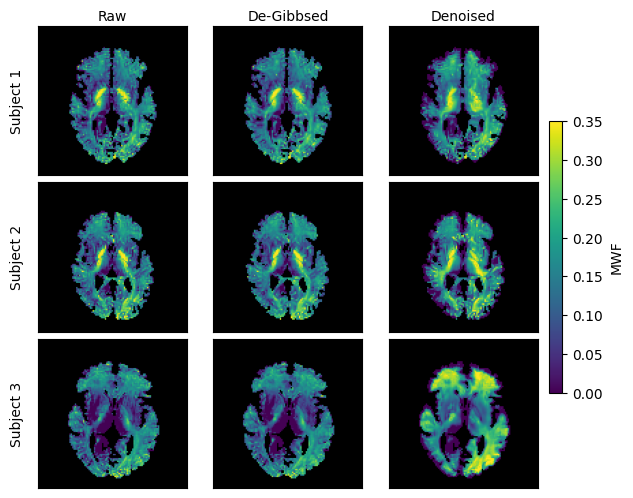

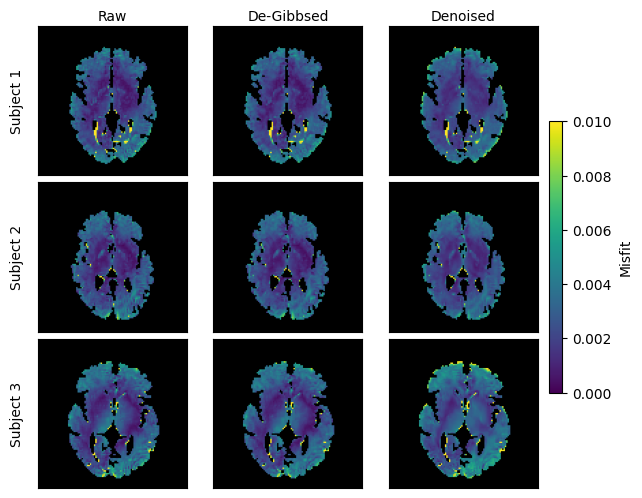

In [17]:
### FIGURE 2: plot and save

save_dir = os.path.join(os.getcwd(), 'ISMRM_2026')
figure_a = 'fig2a.png'
figure_b = 'fig2b.png'
os.makedirs(save_dir, exist_ok=True)

### fig 2a
fig, ax = plt.subplots(3, 3, figsize=(7, 6), gridspec_kw={'hspace': 0.05, 'wspace': 0.05})
cmap = matplotlib.colormaps.get_cmap('viridis')
cmap.set_bad(color='black')

datasets = ['24_10_10_a', '24_10_10_b', '24_10_10_c']
preproc  = ['raw', 'degibbsed', 'denoised']
titles   = ['Raw', 'De-Gibbsed', 'Denoised']
labels   = ['Subject 1', 'Subject 2', 'Subject 3']

for i, ds in enumerate(datasets):
    for j, pp in enumerate(preproc):
        im = ax[i, j].imshow(
            np.rot90(fig_2_data[ds][pp]['T2'][5, :, :, -1]),
            cmap=cmap, vmin=0, vmax=0.35
        )
        if i == 0:
            ax[i, j].set_title(titles[j], fontsize=10, pad=4)
        if j == 0:
            ax[i, j].set_ylabel(labels[i], fontsize=10, labelpad=10)
        
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.025, pad=0.02)
cbar.set_label('MWF', rotation=90, labelpad=5, fontsize=10)

fig.set_facecolor('w')
fig.savefig(f'{os.path.join(save_dir, figure_a)}', dpi=300, format='png', bbox_inches='tight')

plt.show()

### fig 2b
fig, ax = plt.subplots(3, 3, figsize=(7, 6), gridspec_kw={'hspace': 0.05, 'wspace': 0.05})
cmap = matplotlib.colormaps.get_cmap('viridis')
cmap.set_bad(color='black')

datasets = ['24_10_10_a', '24_10_10_b', '24_10_10_c']
preproc  = ['raw', 'degibbsed', 'denoised']
titles   = ['Raw', 'De-Gibbsed', 'Denoised']
labels   = ['Subject 1', 'Subject 2', 'Subject 3']

for i, ds in enumerate(datasets):
    for j, pp in enumerate(preproc):
        im = ax[i, j].imshow(
            np.rot90(fig_2_data[ds][pp]['T2'][6, :, :, -1]),
            cmap=cmap, vmin=0, vmax=0.01
        )
        if i == 0:
            ax[i, j].set_title(titles[j], fontsize=10, pad=4)
        if j == 0:
            ax[i, j].set_ylabel(labels[i], fontsize=10, labelpad=10)
        
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.025, pad=0.02)
cbar.set_label('Misfit', rotation=90, labelpad=5, fontsize=10)

fig.set_facecolor('w')
fig.savefig(f'{os.path.join(save_dir, figure_b)}', dpi=300, format='png', bbox_inches='tight')

plt.show()

{'T1': False, 'T2': True, 'T2S': False, 'CT2S': False, 'SI': True, 'JI': False} norm_obs | norm_syn: True | True
Dataset: 24_10_10_a | Signal: T2 | Pixel: [81, 58] | File: mese_run1_degibbsed.nii

Calling measurement data ...
Spatial gaussian smoothing filter: False
Execution time: 00:00:00 hrs

Applying mask status: True ...
Execution time: 00:00:00 hrs

Calculating system parameters for slice list - [7] ...

Calculating PSO system constants ...
Execution time: 00:00:00 hrs

Starttime for PSO routine (GMT): 15:06:50

Execution time preparation of sys param: : 00:00:36 hrs

Execute PSO on pixel [81,58]: signal - T2 | slice: 07 | noPeaks: GAUSS


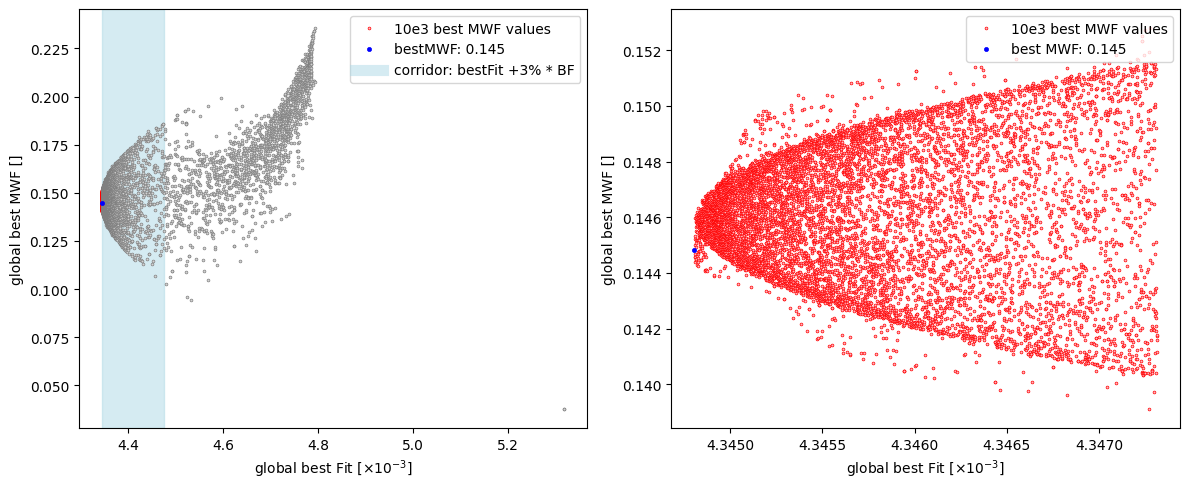


Execution time: 00:00:18 hrs
Dataset: 24_10_10_a | Signal: T2 | Pixel: [34, 67] | File: mese_run1_degibbsed.nii

Calling measurement data ...
Spatial gaussian smoothing filter: False
Execution time: 00:00:00 hrs

Applying mask status: True ...
Execution time: 00:00:00 hrs

Calculating system parameters for slice list - [7] ...

Calculating PSO system constants ...
Execution time: 00:00:00 hrs

Starttime for PSO routine (GMT): 15:08:05

Execution time preparation of sys param: : 00:00:19 hrs

Execute PSO on pixel [34,67]: signal - T2 | slice: 07 | noPeaks: GAUSS


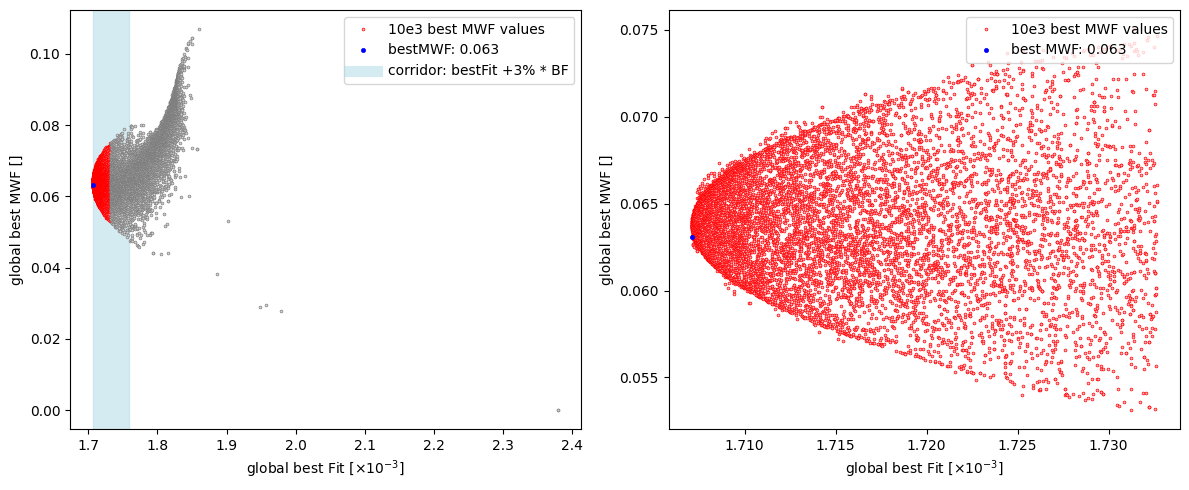


Execution time: 00:00:12 hrs
Dataset: 24_10_10_a | Signal: T2 | Pixel: [59, 60] | File: mese_run1_degibbsed.nii

Calling measurement data ...
Spatial gaussian smoothing filter: False
Execution time: 00:00:00 hrs

Applying mask status: True ...
Execution time: 00:00:00 hrs

Calculating system parameters for slice list - [7] ...

Calculating PSO system constants ...
Execution time: 00:00:00 hrs

Starttime for PSO routine (GMT): 15:09:01

Execution time preparation of sys param: : 00:00:19 hrs

Execute PSO on pixel [59,60]: signal - T2 | slice: 07 | noPeaks: GAUSS


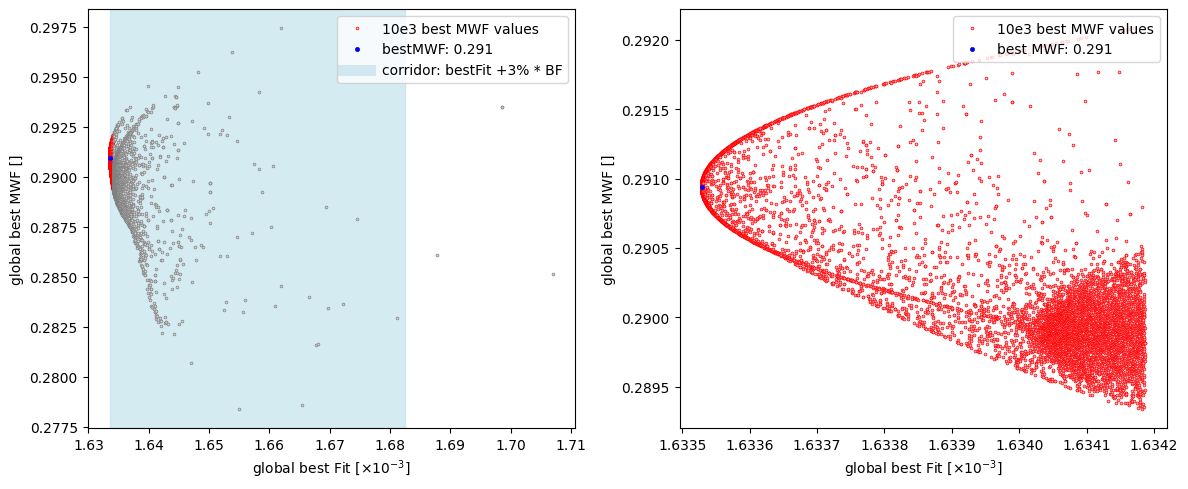


Execution time: 00:00:12 hrs
Dataset: 24_10_10_a | Signal: T2 | Pixel: [61, 42] | File: mese_run1_degibbsed.nii

Calling measurement data ...
Spatial gaussian smoothing filter: False
Execution time: 00:00:00 hrs

Applying mask status: True ...
Execution time: 00:00:00 hrs

Calculating system parameters for slice list - [7] ...

Calculating PSO system constants ...
Execution time: 00:00:00 hrs

Starttime for PSO routine (GMT): 15:09:56

Execution time preparation of sys param: : 00:00:20 hrs

Execute PSO on pixel [61,42]: signal - T2 | slice: 07 | noPeaks: GAUSS


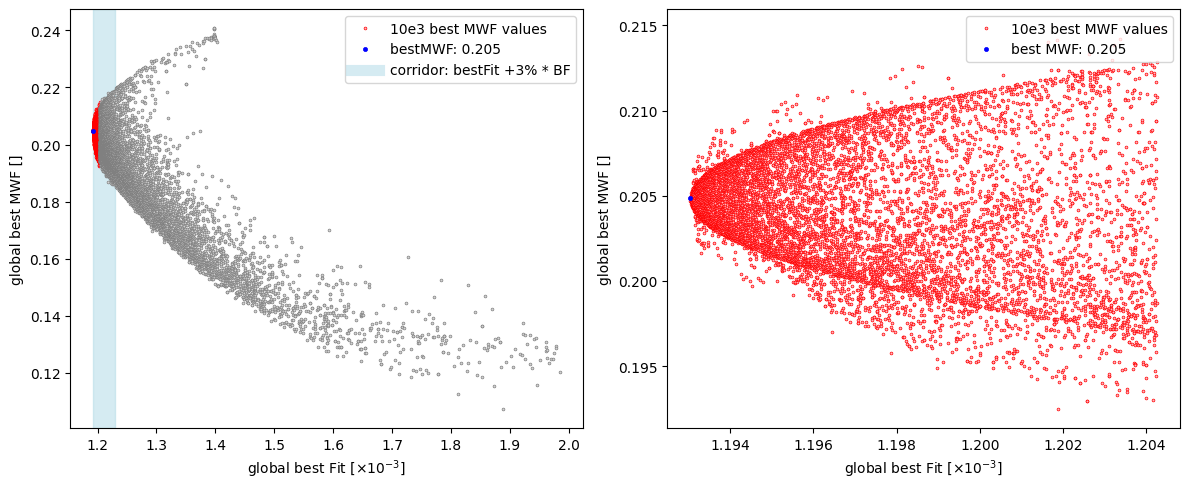


Execution time: 00:00:12 hrs


In [18]:
### FIGURE 3: PSO inversion on in-vivo Gibbs-corrected ME-SE data - subject 1
MRI_signal = 'T2'
data_set   = '24_10_10_a'
T2_file    = 'mese_run1_degibbsed.nii'
slice_num  = 7
runs       = 20000
pixel_list = [[81,58], [34,67], [59,60], [61,42]]

system_parameters = {f'{pixel[0]},{pixel[1]}': [] for pixel in pixel_list}
results_list      = {f'{pixel[0]},{pixel[1]}': [] for pixel in pixel_list}

_config_dict = copy.deepcopy(config_dict)

# Configuration        
if data_set == 'MWF_Atlas':
    _config_dict["source"]["file"]["prj_dir"]   = f'{project_path}/MWF_Atlas/'
    _config_dict["source"]["file"]["TE"]        = 'te_32.npy'
    _config_dict["source"]["data"]["obs_data"]  = 'atlas'
    _config_dict["source"]["data"]["add_noise"] = [True, 150]
    _config_dict["source"]["mask"]["use"]       = False

_config_dict['PSO_spec']['calc']['PSO_on_slice']['use']   = False
_config_dict['PSO_spec']['calc']['PSO_on_pixel']['use']   = True
_config_dict['PSO_spec']['calc']['PSO_on_pixel']['slice'] = slice_num
_config_dict['PSO_spec']['PSO_iter']['pixel']             = runs
_config_dict['source']['file']['prj_dir']                 = f'{project_path}/{data_set}/'
_config_dict['source']['file']['T2']                      = T2_file
_config_dict['PSO_spec']['iter']                          = 15
_config_dict['PSO_spec']['part']                          = 32
_config_dict['PSO_spec']['math']['norm']                  = True

sig_config = dict(_config_dict["source"]["signal"])

for sig in all_signals:
    if MRI_signal == "CT2S":
        sig_config["T2S"]  = True
        sig_config["CT2S"] = True
        sig_config["T1"]   = False
        sig_config["T2"]   = False
    else:
        sig_config[sig] = (sig == MRI_signal)

_config_dict["source"]["signal"] = sig_config
print(sig_config, f'norm_obs | norm_syn: {_config_dict["source"]["data"]["norm_max"]} | {_config_dict["PSO_spec"]["math"]["norm"]}')

for pixel in pixel_list[:]:
    print(f'Dataset: {data_set} | Signal: {item} | Pixel: {pixel} | File: {_config_dict["source"]["file"]["T2"]}')
    
    _config_dict['PSO_spec']['calc']['PSO_on_pixel']['pixel'] = pixel
    results_list[f'{pixel[0]},{pixel[1]}'], system_parameters[f'{pixel[0]},{pixel[1]}'] = run_PSO_SI(config_input=_config_dict, config_type='dict')

fig_3_data  = copy.deepcopy(results_list)
fig_3_param = copy.deepcopy(system_parameters)

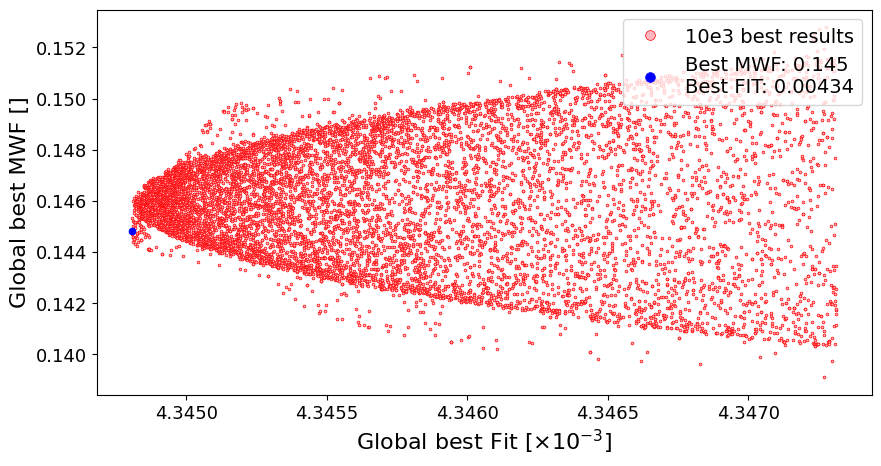

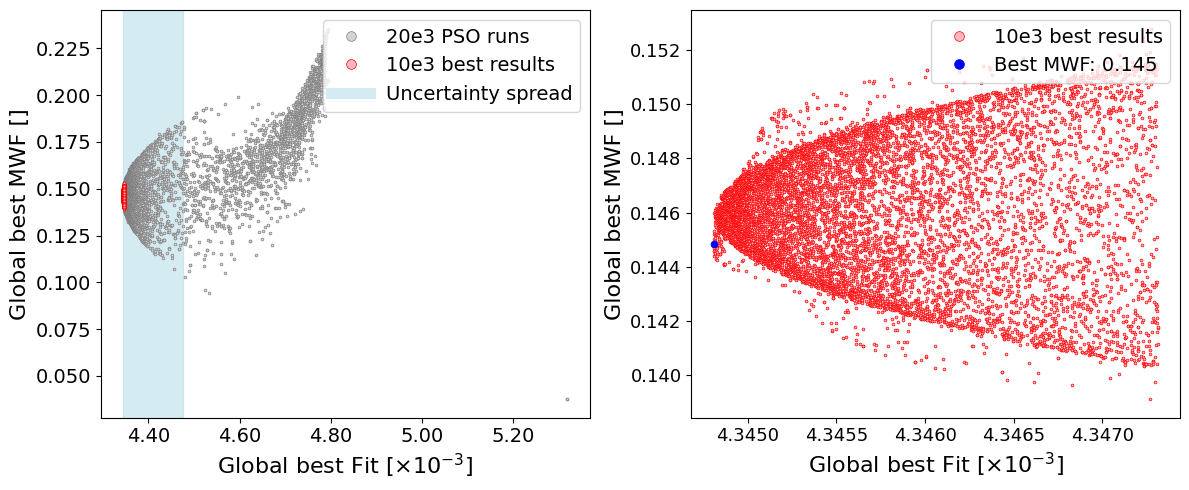

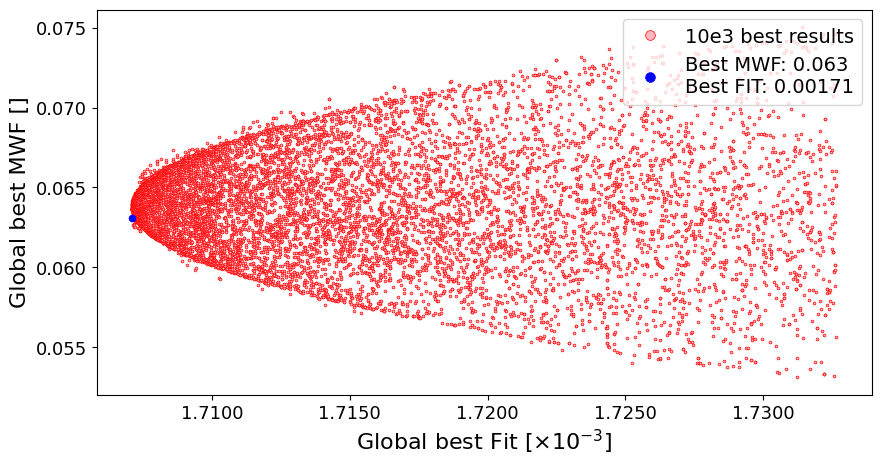

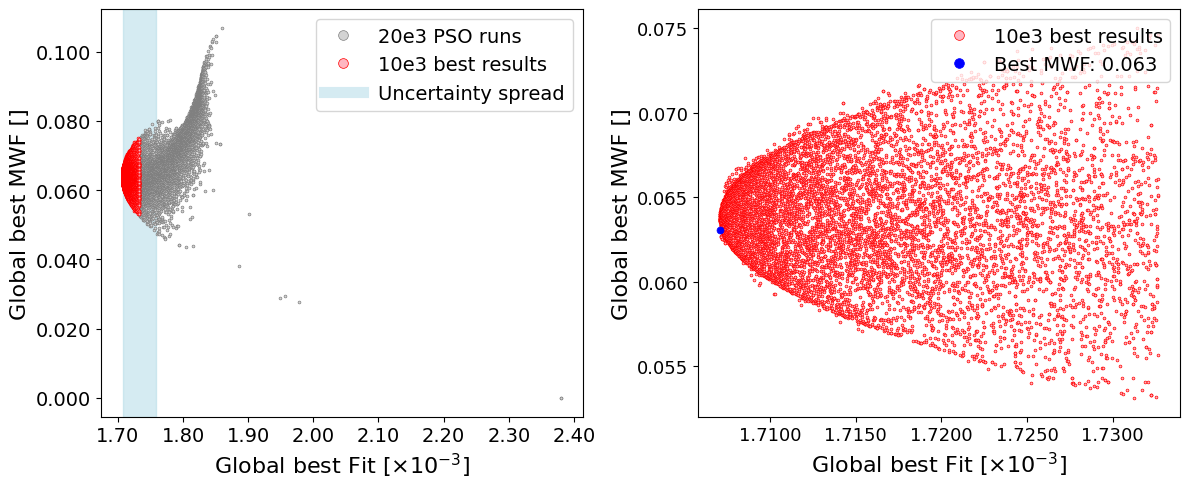

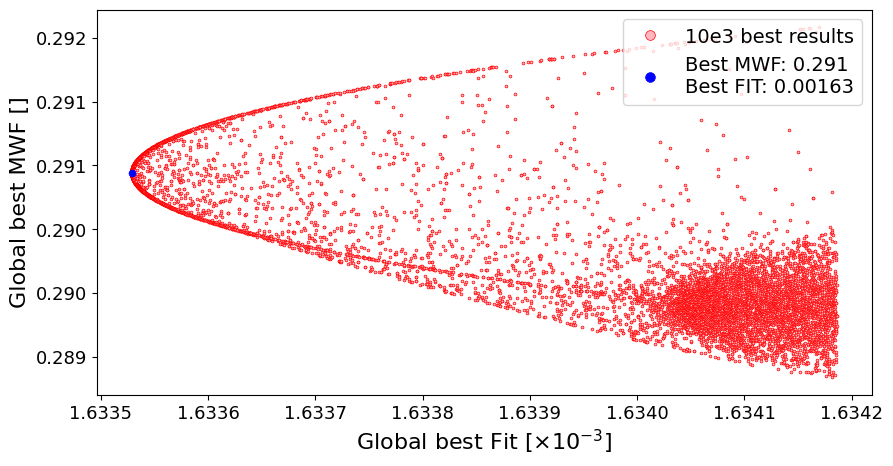

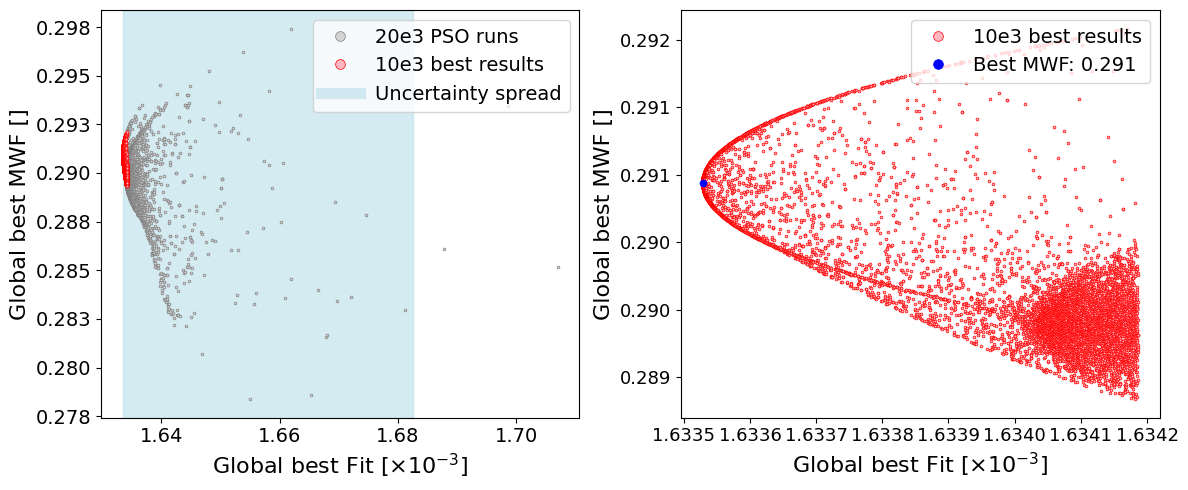

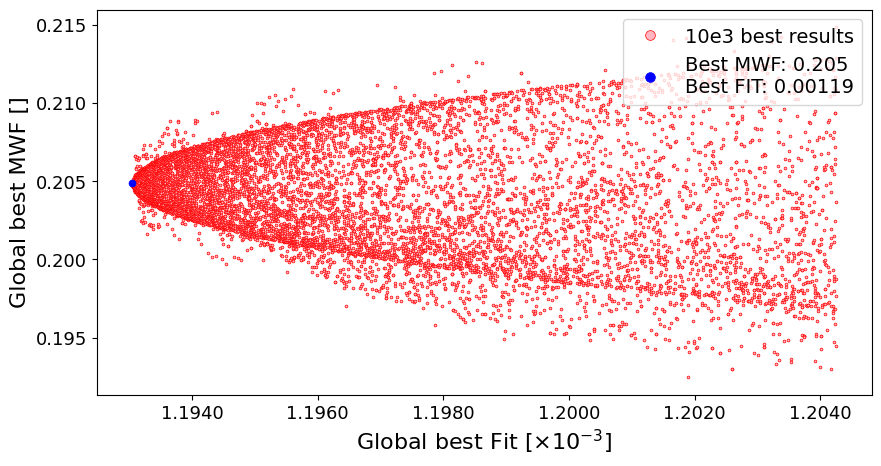

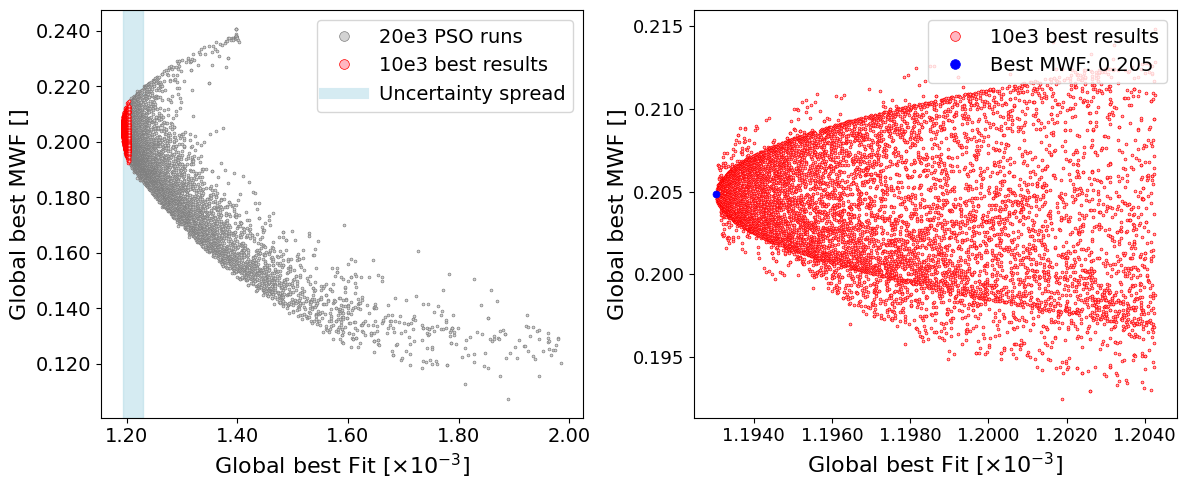

MWF at [58,28]: 0.14493390752611723
MWF at [67,75]: 0.0648576779321705
MWF at [60,50]: 0.2909486774311757
MWF at [42,48]: 0.2051365099767465


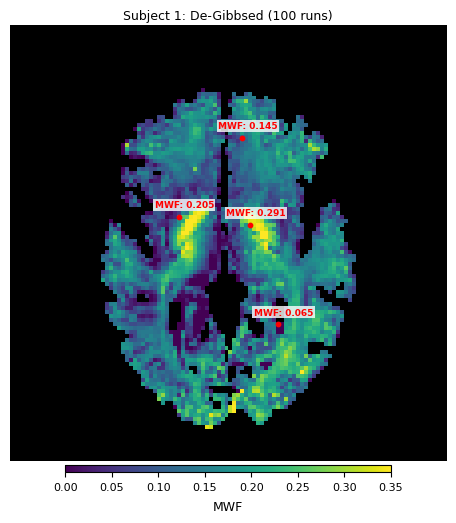

In [20]:
### FIGURE 3: plot and save

signal   = 'T2'
num_val  = 10000       # number of "best of" values
save_dir = os.path.join(os.getcwd(), 'ISMRM_2026')

### Point cloud subfigures

# 0: m1 | 1: m1sig | 2: m2 | 3: m2sig | 4: intFW | 5: MWF | 6,7,8: MW_f, FW_f, phi
for key in list(fig_3_data.keys()):
    MWF   = np.array([r[f"mod{signal}"][5] for r in fig_3_data[key]])
    fits  = np.array([r["fit"]             for r in fig_3_data[key]])

    idx_sorted = np.argsort(fits)
    idx_best   = idx_sorted[:num_val]
    idx_worst  = idx_sorted[num_val:]

    fig2, ax_fig2 = plt.subplots(1, 1, figsize=(10, 5), sharey=False)
    
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

    # Subplot a1
    a1.plot(fits[idx_worst]*1e3, MWF[idx_worst], markersize=2, linestyle='none', marker='o',
            markeredgewidth=0.5, color='gray', markerfacecolor='lightgray',
            label='20e3 PSO runs')    
    
    a1.plot(fits[idx_best]*1e3, MWF[idx_best], markersize=2, linestyle='none', marker='o',
            markeredgewidth=0.5, color='r', markerfacecolor='lightpink',
            label='10e3 best results')      

    low, high = np.min(fits)*1e3, np.min(fits)*1e3*1.03
    a1.axvspan(low, high, color="lightblue", alpha=0.5)
    a1.plot([], [], color="lightblue", linewidth=8, alpha=0.5,
            label='Uncertainty spread')  # label='corridor: bestFit +3% * BF'
    
    leg1 = a1.legend(loc='upper right', fontsize=14)

    for handle in leg1.get_lines():
        handle.set_markersize(7)
    
    a1.set_xlabel(r'Global best Fit [$\times 10^{-3}$]', fontsize=16)
    a1.set_ylabel('Global best MWF []', fontsize=16)
    
    a1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
    a1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
    a1.tick_params(axis='both', labelsize=14)
    
    # Subplot a2
    MWF_of_best_fit = MWF[idx_sorted[np.argmin(fits[idx_sorted])]]

    a2.plot(fits[idx_best]*1e3, MWF[idx_best], markersize=2, linestyle='none', marker='o',
            markeredgewidth=0.5, color='r', markerfacecolor='lightpink',
            label='10e3 best results')
    
    a2.plot(np.min(fits[idx_best])*1e3, MWF_of_best_fit,
            markersize=5, linestyle='none', marker='o', markeredgewidth=0.5,
            color='b', label=f'Best MWF: {np.round(MWF_of_best_fit,3)}')

    leg2 = a2.legend(loc='upper right', fontsize=14)

    for handle in leg2.get_lines():
        handle.set_markersize(7)
        
    a2.set_ylabel('Global best MWF []', fontsize=16)    
    a2.set_xlabel(r'Global best Fit [$\times 10^{-3}$]', fontsize=16)

    a2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.4f}'))
    a2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
    a2.tick_params(axis='both', labelsize=13)
      
    fig.savefig(f'{save_dir}/fig3_{key}.png', dpi=300, format='png', bbox_inches='tight')

    ##
    ax_fig2.plot(fits[idx_best]*1e3, MWF[idx_best], markersize=2, linestyle='none', marker='o',
            markeredgewidth=0.5, color='r', markerfacecolor='lightpink',
            label='10e3 best results')
    ax_fig2.plot(np.min(fits[idx_best])*1e3, MWF_of_best_fit,
            markersize=5, linestyle='none', marker='o', markeredgewidth=0.5,
            color='b', label=f'Best MWF: {np.round(MWF_of_best_fit,3)}\nBest FIT: {np.round(np.min(fits),5)}')

    leg3 = ax_fig2.legend(loc='upper right', fontsize=14)

    for handle in leg3.get_lines():
        handle.set_markersize(7)

    ax_fig2.set_ylabel('Global best MWF []', fontsize=16)    
    ax_fig2.set_xlabel(r'Global best Fit [$\times 10^{-3}$]', fontsize=16)

    ax_fig2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.4f}'))
    ax_fig2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
    ax_fig2.tick_params(axis='both', labelsize=13)
    
    fig2.savefig(f'{save_dir}/fig3_{key}_10000best.png', dpi=300, format='png', bbox_inches='tight')

    plt.tight_layout()    
    plt.show()

### centered MWF figure: for this you need to run the cell for PSO inversion on ME-SE data FIGURE 2
pixel_list = [[81,58], [34,67], [59,60], [61,42]]

cmap = matplotlib.colormaps.get_cmap('viridis')
cmap.set_bad(color='black')

image     = fig_2_data['24_10_10_a']['degibbsed']['T2'][5, :, :, -1]
image_rot = np.rot90(image)
# after rotation: (x, y) → (new_x, new_y) = (y, width - 1 - x)
height, width = image_rot.shape

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(image_rot, cmap=cmap, vmin=0, vmax=0.35)

for x, y in pixel_list:
    ax.scatter(y, width-1-x, color='red', s=10)
    plt.text(y-6, width-1-x-3, 
             f'MWF: {image_rot[height-1-y,x]:.3f}', 
             color='red', fontsize=6.5, fontweight='bold', 
             va='center', ha='left',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
    print(f'MWF at [{y},{width-1-x}]: {image_rot[height-1-y,x]}')

ax.axis('off')
ax.set_title('Subject 1: De-Gibbsed (100 runs)', fontsize=9, pad=4)
ax.set_xticks([0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35])
ax.set_xticklabels(['0.0', '0.05', '0.1', '0.15', '0.2', '0.25', '0.3', '0.35'], fontsize=1)

cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.046, pad=0.01, shrink=0.7, aspect=50)
cbar.set_label('MWF', rotation=0, labelpad=6, fontsize=9)
cbar.ax.tick_params(labelsize=8)

plt.savefig(f'{save_dir}/fig3_MWF.png', dpi=300, format='png', bbox_inches='tight')

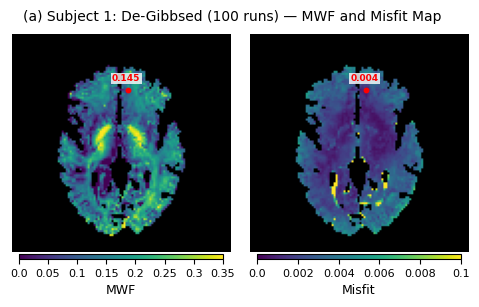

In [22]:
### PREVIEW FIGURE: plot and save
# !!! for this you need to run the cell for PSO inversion on ME-SE data FIGURE 2

pixel_list = [[81,58], [34,67], [59,60], [61,42]]
save_dir   = 'F:/JIMM2/ISMRM_2026/test/'

cmap = matplotlib.colormaps.get_cmap('viridis')
cmap.set_bad(color='black')

image     = fig_2_data['24_10_10_a']['degibbsed']['T2'][5, :, :, -1]
misfit    = fig_2_data['24_10_10_a']['degibbsed']['T2'][6, :, :, -1]
image_rot = np.rot90(image)
mfit_rot  = np.rot90(misfit)

# after rotation: (x, y) → (new_x, new_y) = (y, width - 1 - x)
height, width = image_rot.shape

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(6, 3), gridspec_kw={'wspace': 0.05})
im_data = ax[0].imshow(image_rot, cmap=cmap, vmin=0, vmax=0.35)
ax[0].axis('off')
im_mfit = ax[1].imshow(mfit_rot, cmap=cmap, vmin=0, vmax=0.01)
ax[1].axis('off')

for x, y in pixel_list[:1]:
    ax[0].scatter(y, width-1-x, color='red', s=10)
    ax[0].text(y-8, width-7-x, 
             f'{image_rot[height-1-y,x]:.3f}', 
             color='red', fontsize=6.5, fontweight='bold', 
             va='center', ha='left',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

    ax[1].scatter(y, width-1-x, color='red', s=10)
    ax[1].text(y-8, width-7-x, 
         f'{mfit_rot[height-1-y,x]:.3f}', 
         color='red', fontsize=6.5, fontweight='bold', 
         va='center', ha='left',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

fig.suptitle('(a) Subject 1: De-Gibbsed (100 runs) — MWF and Misfit Map', fontsize=10, y=0.96)

cbar1 = fig.colorbar(im_data, ax=ax[0], orientation='horizontal', fraction=0.046, pad=0.01, shrink=0.9, aspect=45)
cbar1.set_label('MWF', rotation=0, labelpad=4, fontsize=9)
cbar1.ax.set_xticks([0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35])
cbar1.ax.set_xticklabels(['0.0', '0.05', '0.1', '0.15', '0.2', '0.25', '0.3', '0.35'])
cbar1.ax.tick_params(labelsize=8)

cbar2 = fig.colorbar(im_mfit, ax=ax[1], orientation='horizontal', fraction=0.046, pad=0.01, shrink=0.9, aspect=45)
cbar2.set_label('Misfit', rotation=0, labelpad=4, fontsize=9)
cbar2.ax.set_xticks([0.0, 0.002, 0.004, 0.006, 0.008, 0.01])
cbar2.ax.set_xticklabels(['0.0', '0.002', '0.004', '0.006', '0.008', '0.1'])
cbar2.ax.tick_params(labelsize=8)

plt.savefig(f'{save_dir}/fig0_preview.png', dpi=300, format='png', bbox_inches='tight')